# GraphRAG Benchmark — 3 Approaches Compared
## Gemini RAG (Semantic) vs GraphRAG (Subgraph-as-Context) vs Text2Cypher (NL2Query)
### LLM: Gemma 3 27B (`gemma-3-27b-it`) · Embeddings: `gemini-embedding-001`

> **Note:** Text2Cypher is NOT RAG. It's NL2Query — the LLM generates a Cypher query instead of retrieving chunks.
> **GraphRAG** uses vector search to find a seed node, then traverses the graph to build a subgraph context — the graph topology is used at retrieval time, not just at index time.

### Setup
```bash
pip install neo4j google-genai networkx scikit-learn pandas matplotlib seaborn tqdm python-dotenv
```

## 1. Imports & Configuration

In [35]:
%pip install neo4j google-genai networkx scikit-learn pandas matplotlib seaborn tqdm python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [36]:

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

import networkx as nx
from neo4j import GraphDatabase
from google import genai
from google.genai import types
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

load_dotenv()

# ── CONFIG ──
NEO4J_URI      = os.getenv("NEO4J_URI",      "bolt://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER",     "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

EMBED_MODEL = "gemini-embedding-001"   # embeddings — Gemma doesn't support this
LLM_MODEL   = "gemma-3-27b-it"        # generation (RAG answers, Text2Cypher)
EMBED_DIMS  = 256
TOP_K       = 3

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as s:
    ok = s.run("RETURN 1 AS ok").single()["ok"]
print(f"Neo4j connected: {ok == 1}")
print(f"Gemini client ready: {bool(GEMINI_API_KEY)}")


Neo4j connected: True
Gemini client ready: True


## 2. Extract Graph from Neo4j

In [37]:

def extract_graph():
    """Extrait le graphe complet depuis Neo4j."""
    with driver.session() as s:
        nodes = s.run("""
            MATCH (n)
            RETURN elementId(n) AS id,
                   labels(n)[0] AS label,
                   properties(n) AS props
        """).data()

        edges = s.run("""
            MATCH (a)-[r]->(b)
            RETURN elementId(a) AS src,
                   elementId(b) AS dst,
                   type(r)      AS rel
        """).data()

    G = nx.Graph()
    node_meta  = {}
    product_ids = {}  # code -> neo4j_id

    for n in nodes:
        G.add_node(n["id"])
        node_meta[n["id"]] = {"label": n["label"], "props": n["props"]}
        if n["label"] == "Product":
            product_ids[n["props"].get("code", "")] = n["id"]

    for e in edges:
        G.add_edge(e["src"], e["dst"], rel=e["rel"])

    return G, node_meta, product_ids

G, node_meta, product_ids = extract_graph()

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Products : {len(product_ids)}")
print(f"\nProduct codes sample: {list(product_ids.keys())[:5]}")


Nodes : 70798
Edges : 71272
Products : 40

Product codes sample: ['AT5X5K', 'ATN01K24P', 'ATN02K12P', 'ATPA1K24P', 'ATPPCH5X5K']


## 3. Graph Structure Visualization

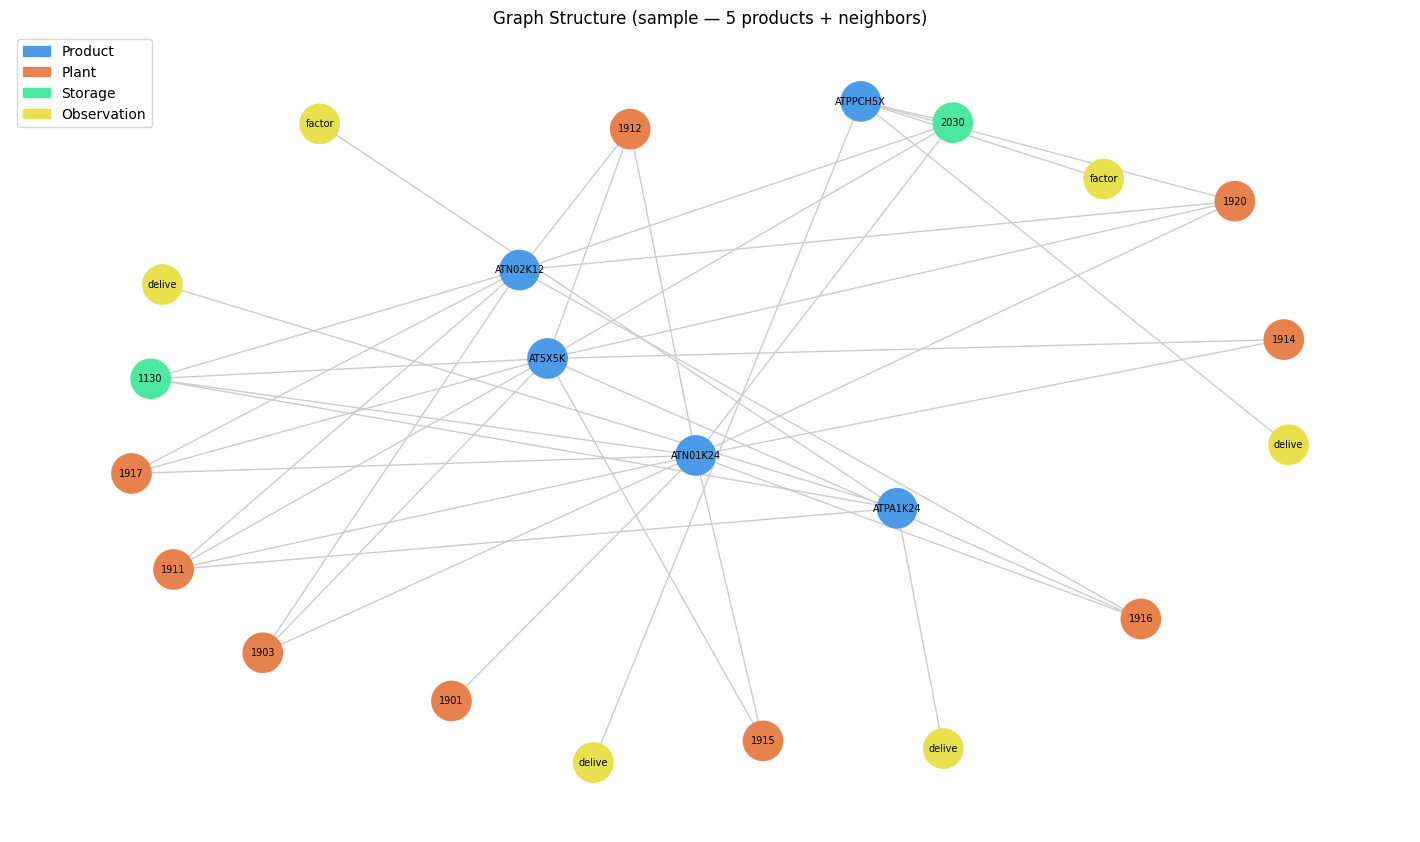

In [38]:

# Visualiser le graphe (sous-ensemble pour lisibilité)
label_colors = {
    "Product":     "#4C9BE8",
    "Plant":       "#E8824C",
    "Storage":     "#4CE8A0",
    "Observation": "#E8E04C"
}

# Prendre un sous-graphe autour des premiers produits
sample_products = list(product_ids.values())[:5]
subgraph_nodes = set(sample_products)
for p in sample_products:
    subgraph_nodes.update(list(G.neighbors(p))[:5])

SG = G.subgraph(subgraph_nodes)

colors = [label_colors.get(node_meta.get(n, {}).get("label", "Product"), "#999")
          for n in SG.nodes()]
labels_map = {}
for n in SG.nodes():
    meta = node_meta.get(n, {})
    props = meta.get("props", {})
    label = meta.get("label", "?")
    if label == "Product":
        labels_map[n] = props.get("code", str(n))[:8]
    elif label == "Observation":
        labels_map[n] = props.get("metric", "obs")[:6]
    else:
        labels_map[n] = str(props.get("id", str(n)))[:6]

plt.figure(figsize=(14, 8))
pos = nx.spring_layout(SG, seed=42, k=2)
nx.draw(SG, pos, node_color=colors, labels=labels_map,
        node_size=800, font_size=7, edge_color="#ccc", with_labels=True)

# Légende
from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in label_colors.items()]
plt.legend(handles=legend, loc="upper left")
plt.title("Graph Structure (sample — 5 products + neighbors)")
plt.tight_layout()
plt.show()


## 4. Approach A — Gemini Text Embeddings (Semantic RAG)
A rich descriptive text is built for each product by aggregating graph data,
then embedded with `gemini-embedding-001`.

✅ **Advantage**: Query and documents share the **same semantic space**.

In [39]:

def build_product_text(record: dict) -> str:
    """Construit un texte descriptif riche pour un produit depuis le graphe."""
    code     = record.get("code", "?")
    grp      = record.get("grp")      or "unknown"
    subgroup = record.get("subgroup") or "unknown"
    plants   = record.get("plants")   or []
    storages = record.get("storages") or []
    obs      = record.get("obs")      or []

    metrics = defaultdict(list)
    for o in obs:
        if not o or o.get("metric") is None or o.get("value") is None:
            continue
        metrics[f"{o['metric']}_{o['unit']}"].append(float(o["value"]))

    metric_lines = [
        f"{k.split('_')[0]} ({k.split('_')[1]}): avg={np.mean(v):.2f} total={sum(v):.2f}"
        for k, v in metrics.items()
    ]

    return (
        f"Product {code}, group {grp}, subgroup {subgroup}. "
        f"Plants: {', '.join(str(p) for p in plants) or 'none'}. "
        f"Storages: {', '.join(str(s) for s in storages) or 'none'}. "
        f"Metrics: {'; '.join(metric_lines) or 'none'}."
    )

# Récupérer les données complètes
with driver.session() as s:
    product_data = s.run("""
        MATCH (p:Product)
        OPTIONAL MATCH (p)-[:ASSIGNED_TO_PLANT]->(pl:Plant)
        OPTIONAL MATCH (p)-[:STORED_IN]->(st:Storage)
        OPTIONAL MATCH (p)-[:HAS_OBSERVATION]->(o:Observation)
        WITH p,
             collect(DISTINCT pl.id) AS plants,
             collect(DISTINCT st.id) AS storages,
             collect(DISTINCT {metric: o.metric, unit: o.unit_type, value: o.value}) AS obs
        RETURN p.code AS code, p.group AS grp, p.subgroup AS subgroup,
               plants, storages, obs
    """).data()

product_texts = {r["code"]: build_product_text(r) for r in product_data}
print("Sample text for first product:")
print(list(product_texts.values())[0])


Sample text for first product:
Product AT5X5K, group A, subgroup AT. Plants: 1903, 1911, 1912, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922. Storages: 1730, 1530, 1630, 1830, 1430, 2030, 1230, 2130, 2230, 1130, 1930, 330. Metrics: factory (issue): avg=940.99 total=159028.00; production (weight): avg=26.02 total=520.35; sales (order): avg=1060.11 total=169618.20; production (unit): avg=1040.70 total=20814.00; delivery (unit): avg=859.25 total=175286.14; delivery (weight): avg=21.48 total=4382.15; sales (order): avg=26.50 total=4240.46; factory (issue): avg=23.52 total=3975.70.


In [40]:

EMBED_CACHE = "embeddings/gemini_products.npz"
os.makedirs("embeddings", exist_ok=True)

def gemini_embed(text: str, task_type: str = "RETRIEVAL_DOCUMENT") -> np.ndarray:
    result = gemini_client.models.embed_content(
        model=EMBED_MODEL,
        contents=text,
        config=types.EmbedContentConfig(
            task_type=task_type,
            output_dimensionality=EMBED_DIMS
        )
    )
    return np.array(result.embeddings[0].values)

# Load from cache if it exists, otherwise generate and save
if os.path.exists(EMBED_CACHE):
    data = np.load(EMBED_CACHE, allow_pickle=True)
    gemini_embeddings = dict(zip(data["codes"].tolist(), data["embeddings"]))
    print(f"Loaded from cache: {len(gemini_embeddings)} embeddings x {EMBED_DIMS}d")
else:
    print("Generating Gemini embeddings (free tier: ~15 RPM)...")
    gemini_embeddings = {}
    for i, record in enumerate(tqdm(product_data, desc="Gemini embeddings")):
        if i > 0 and i % 10 == 0:
            time.sleep(8)   # stay well under 15 RPM
        gemini_embeddings[record["code"]] = gemini_embed(product_texts[record["code"]])

    codes_arr = np.array(list(gemini_embeddings.keys()), dtype=object)
    emb_arr   = np.vstack([gemini_embeddings[c] for c in codes_arr]).astype(np.float32)
    np.savez_compressed(EMBED_CACHE, codes=codes_arr, embeddings=emb_arr)
    print(f"Saved to {EMBED_CACHE}")

print(f"Gemini embeddings: {len(gemini_embeddings)} x {EMBED_DIMS}d")


Loaded from cache: 40 embeddings x 256d
Gemini embeddings: 40 x 256d


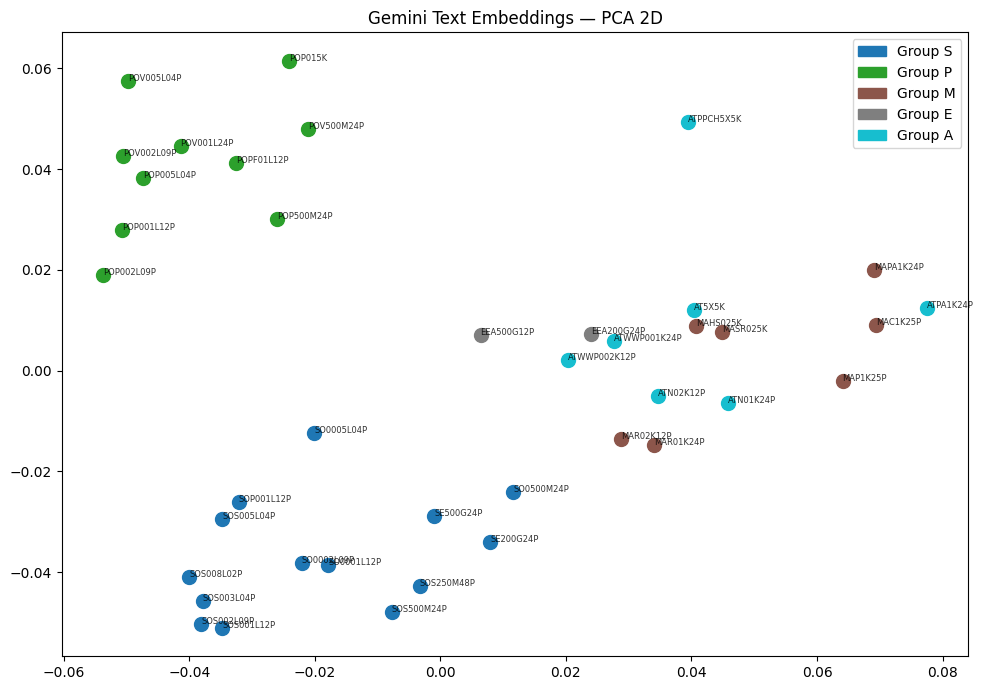

In [41]:

# PCA visualization of Gemini embeddings
codes_g  = list(gemini_embeddings.keys())
matrix_g = np.stack([gemini_embeddings[c] for c in codes_g])

with driver.session() as s:
    product_info = {
        r["code"]: {"group": r["group"], "subgroup": r["subgroup"]}
        for r in s.run("MATCH (p:Product) RETURN p.code AS code, p.group AS group, p.subgroup AS subgroup").data()
    }

groups_g     = [product_info.get(c, {}).get("group", "?") for c in codes_g]
unique_groups = list(set(groups_g))
palette       = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
color_map     = dict(zip(unique_groups, palette))

coords_g = PCA(n_components=2).fit_transform(matrix_g)

plt.figure(figsize=(10, 7))
for i, code in enumerate(codes_g):
    g = groups_g[i]
    plt.scatter(coords_g[i, 0], coords_g[i, 1], color=color_map.get(g, "gray"), s=100, zorder=3)
    plt.annotate(code, (coords_g[i, 0], coords_g[i, 1]), fontsize=6, alpha=0.8)

plt.legend(handles=[Patch(color=color_map.get(g, "gray"), label=f"Group {g}") for g in unique_groups])
plt.title("Gemini Text Embeddings — PCA 2D")
plt.tight_layout()
plt.show()


## 5. Approach B — Text2Cypher (NL2Query — NOT RAG)

> **This is not RAG.** The LLM generates an exact Cypher query,
> executed directly on Neo4j. Precise results, no vector approximation.

**Advantages:** Perfect precision on structured data, no embeddings needed.  
**Limitations:** The LLM must know the graph schema and may generate invalid Cypher.

In [42]:

# Schéma du graphe (fourni au LLM pour générer le bon Cypher)
GRAPH_SCHEMA = """
Nodes:
  - Product {code: string, group: string, subgroup: string}
  - Plant {id: string}
  - Storage {id: string}
  - Observation {obs_key: string, date: date, metric: string, unit_type: string, value: float}

Relationships:
  - (Product)-[:ASSIGNED_TO_PLANT]->(Plant)
  - (Product)-[:STORED_IN]->(Storage)
  - (Product)-[:HAS_OBSERVATION]->(Observation)

Metrics available: delivery, factory_issue, production, sales_order
Unit types: unit, weight
Date range: 2023-01-01 to 2023-08-09
"""

TEXT2CYPHER_PROMPT = """You are a Neo4j Cypher expert.
Given the graph schema and a question, generate a valid Cypher query.
Return ONLY the Cypher query, no explanation, no markdown.

Schema:
{schema}

Question: {question}

Cypher:"""

def text2cypher(question: str) -> dict:
    """Génère et exécute une requête Cypher depuis une question en langage naturel."""
    # 1. Générer le Cypher
    prompt = TEXT2CYPHER_PROMPT.format(schema=GRAPH_SCHEMA, question=question)
    response = gemini_client.models.generate_content(model=LLM_MODEL, contents=prompt)
    cypher = response.text.strip().strip("```").replace("cypher\n", "").strip()

    # 2. Exécuter dans Neo4j
    try:
        with driver.session() as s:
            results = s.run(cypher).data()
        return {"cypher": cypher, "results": results, "error": None}
    except Exception as e:
        return {"cypher": cypher, "results": [], "error": str(e)}

# Test
test_q = "Which products are assigned to plant 1903?"
t2c_result = text2cypher(test_q)
print(f"Question: {test_q}")
print(f"Generated Cypher:\n{t2c_result['cypher']}")
print(f"\nResults: {t2c_result['results'][:3]}")
if t2c_result['error']:
    print(f"Error: {t2c_result['error']}")


Question: Which products are assigned to plant 1903?
Generated Cypher:
MATCH (p:Product)-[:ASSIGNED_TO_PLANT]->(plant:Plant) WHERE plant.id = '1903' RETURN p

Results: [{'p': {'subgroup': 'MAR', 'code': 'MAR02K12P', 'group': 'M'}}, {'p': {'subgroup': 'MAR', 'code': 'MAR01K24P', 'group': 'M'}}, {'p': {'subgroup': 'SE', 'code': 'SE500G24P', 'group': 'S'}}]


## 6. Approach C — GraphRAG (Subgraph-as-Context)

This is genuine GraphRAG. The graph topology is used **at retrieval time**, not just at index time.

**Pipeline:**
1. Embed the query → find the top matching product (vector step, same as Semantic RAG)
2. **Traverse the graph** from the seed node in Neo4j:
   - Direct connections: plants, storages
   - 2-hop neighbors: products that share the same plants (structural siblings)
   - Aggregated metrics for seed and siblings
3. Serialize the **subgraph** (nodes + edges + attributes) as structured context
4. Pass the subgraph context to Gemma 3 27B to reason over graph relationships

**Key difference from Semantic RAG:** Semantic RAG retrieves 3 independent product documents. GraphRAG retrieves 1 seed product and expands it through the graph — the context shows *who is connected to whom and why*.

In [43]:

def graphrag_retrieve(query_embedding: np.ndarray, top_k_seed: int = 1) -> str:
    """
    GraphRAG — subgraph-as-context retrieval.

    Step 1: cosine similarity → seed product node(s)
    Step 2: Neo4j graph traversal → direct connections (plants, storages)
                                  → 2-hop siblings (products sharing same plants)
    Step 3: serialize subgraph (nodes + relationships + metrics) as context

    Unlike flat RAG (top-K independent documents), the context here encodes
    graph topology: which products share which infrastructure, and their metrics.
    """
    # Step 1 — find seed node(s) by vector similarity
    codes  = list(gemini_embeddings.keys())
    matrix = np.stack([gemini_embeddings[c] for c in codes])
    sims   = cosine_similarity([query_embedding], matrix)[0]
    seeds  = [codes[i] for i in np.argsort(sims)[::-1][:top_k_seed]]

    # Step 2 — traverse graph neighborhood from seed(s)
    with driver.session() as s:
        rows = s.run("""
            UNWIND $seeds AS seedCode
            MATCH (seed:Product {code: seedCode})
            OPTIONAL MATCH (seed)-[:ASSIGNED_TO_PLANT]->(pl:Plant)
            OPTIONAL MATCH (seed)-[:STORED_IN]->(st:Storage)
            OPTIONAL MATCH (seed)-[:ASSIGNED_TO_PLANT]->(:Plant)<-[:ASSIGNED_TO_PLANT]-(sib:Product)
              WHERE sib.code <> seed.code
            OPTIONAL MATCH (seed)-[:HAS_OBSERVATION]->(o:Observation)
            WITH seed,
                 collect(DISTINCT pl.id)            AS plants,
                 collect(DISTINCT st.id)            AS storages,
                 collect(DISTINCT sib.code)[0..5]   AS siblings,
                 collect(DISTINCT {metric: o.metric, unit: o.unit_type,
                                   value: o.value}) AS obs
            RETURN seed.code AS code, seed.group AS grp, seed.subgroup AS subgroup,
                   plants, storages, siblings, obs
        """, seeds=seeds).data()

    # Step 3 — fetch sibling metrics (2nd hop, Neo4j only — no extra API call)
    all_siblings = list({sc for r in rows for sc in r.get("siblings", [])})
    sib_metrics  = {}
    if all_siblings:
        with driver.session() as s:
            for row in s.run("""
                UNWIND $codes AS c
                MATCH (p:Product {code: c})-[:HAS_OBSERVATION]->(o:Observation)
                WITH p.code AS code, o.metric AS metric, o.unit_type AS unit,
                     avg(o.value) AS avg_val
                RETURN code, metric, unit, avg_val
            """, codes=all_siblings).data():
                sib_metrics.setdefault(row["code"], []).append(
                    f"{row['metric']} ({row['unit']}): avg={row['avg_val']:.2f}")

    # Step 4 — serialize subgraph as structured context
    sections = []
    for r in rows:
        m = defaultdict(list)
        for o in r["obs"]:
            if o and o.get("metric") and o.get("value") is not None:
                m[f"{o['metric']} ({o['unit']})"].append(float(o["value"]))
        metric_lines = [f"    {k}: avg={np.mean(v):.2f}, total={sum(v):.2f}"
                        for k, v in m.items()]
        sib_lines = [f"    - {sc}: {'; '.join(sib_metrics.get(sc, [])[:3])}"
                     for sc in r["siblings"]]

        sections.append(
            f"[SEED NODE] Product {r['code']} | Group {r['grp']} | Subgroup {r['subgroup']}\n"
            f"  Plants   : {', '.join(map(str, r['plants'])) or 'none'}\n"
            f"  Storages : {', '.join(map(str, r['storages'])) or 'none'}\n"
            f"  Metrics (seed):\n" + ("\n".join(metric_lines) or "    none") + "\n"
            f"  [2-HOP] Products sharing same plants (structural siblings):\n" +
            ("\n".join(sib_lines) or "    none")
        )
    return "\n\n---\n\n".join(sections)


def graphrag_answer(question: str, subgraph_context: str) -> str:
    prompt = f"""You are a supply chain analyst reasoning over a knowledge graph.

The context below is a SUBGRAPH retrieved by traversing the graph from the most query-relevant product node.
It includes:
- The seed product node (most similar to the query)
- Its direct graph connections: plants and storage locations
- 2-hop neighbors: products reachable via shared plants (structural siblings)
- Aggregated metrics for seed and siblings

Use the graph structure and relationships — not just individual product facts — to answer.

SUBGRAPH CONTEXT:
{subgraph_context}

QUESTION: {question}

ANSWER:"""
    resp = gemini_client.models.generate_content(model=LLM_MODEL, contents=prompt)
    return resp.text


# Test
test_q   = "Which products are most similar to AT5X5K in terms of supply chain behavior?"
test_emb = gemini_embed(test_q, task_type="RETRIEVAL_QUERY")
test_ctx = graphrag_retrieve(test_emb, top_k_seed=1)
print("Subgraph context for test query:")
print(test_ctx[:800], "...")


Subgraph context for test query:
[SEED NODE] Product AT5X5K | Group A | Subgroup AT
  Plants   : 1903, 1911, 1912, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922
  Storages : 1730, 1530, 1630, 1830, 1430, 2030, 1230, 2130, 2230, 1130, 1930, 330
  Metrics (seed):
    factory_issue (unit): avg=940.99, total=159028.00
    production (weight): avg=26.02, total=520.35
    sales_order (unit): avg=1060.11, total=169618.20
    production (unit): avg=1040.70, total=20814.00
    delivery (unit): avg=859.25, total=175286.14
    delivery (weight): avg=21.48, total=4382.15
    sales_order (weight): avg=26.50, total=4240.46
    factory_issue (weight): avg=23.52, total=3975.70
  [2-HOP] Products sharing same plants (structural siblings):
    - MAR02K12P: delivery (weight): avg=2.53; sales_order (unit): avg=119.63; factory_issue (u ...


## 7. Unified Retrieval Functions

In [44]:

def vector_retrieve(query_embedding: np.ndarray,
                    doc_embeddings: dict,
                    doc_texts: dict,
                    top_k: int = TOP_K) -> list[dict]:
    """Retrieval vectoriel générique."""
    codes  = list(doc_embeddings.keys())
    matrix = np.stack([doc_embeddings[c] for c in codes])
    sims   = cosine_similarity([query_embedding], matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [
        {"code": codes[i], "score": float(sims[i]),
         "text": doc_texts.get(codes[i], "")}
        for i in top_idx
    ]

def rag_answer(question: str, context: str) -> str:
    """Génère une réponse RAG avec Gemini."""
    prompt = f"""You are a supply chain analyst. Answer using ONLY the context.
Be precise with codes and numbers.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""
    resp = gemini_client.models.generate_content(model=LLM_MODEL, contents=prompt)
    return resp.text

def t2c_answer(question: str, results: list, cypher: str) -> str:
    """Génère une réponse lisible depuis les résultats Cypher."""
    prompt = f"""You are a supply chain analyst.
The following data was retrieved from a graph database using this Cypher query:

Cypher: {cypher}
Data: {results}

Answer this question concisely: {question}"""
    resp = gemini_client.models.generate_content(model=LLM_MODEL, contents=prompt)
    return resp.text


## 8. Benchmark — 6 Questions (Mixed Types)

Questions are split by type to expose each approach's strengths and weaknesses:
- **Structural / Analytical** → Text2Cypher advantage (exact graph lookups)
- **Semantic / Reasoning** → Gemini RAG and GraphRAG advantage (vector similarity + LLM reasoning)

Evaluation uses **LLM-as-judge** (Gemma 3 27B scores each answer 1–5 on correctness, completeness, and clarity).

In [45]:

import json, re

TEST_QUESTIONS = [
    # ── Text2Cypher advantage: exact graph lookups ──
    {"question": "Which products are assigned to plant 1903?",
     "type": "structural"},
    {"question": "Which products belong to group A?",
     "type": "structural"},
    {"question": "What is the total delivery in units for products in subgroup ATN?",
     "type": "analytical"},

    # ── Gemini RAG / GraphRAG advantage: semantic + reasoning ──
    {"question": "Which products are most similar to AT5X5K in terms of supply chain behavior and metrics?",
     "type": "semantic"},
    {"question": "Based on production and delivery data, which products appear to have supply chain risks or underperformance?",
     "type": "reasoning"},
    {"question": "Compare the operational profiles of group A versus group M products. What are the key differences?",
     "type": "reasoning"},
]

JUDGE_PROMPT = """You are evaluating an answer to a supply chain question.
Score the answer on each criterion from 1 (poor) to 5 (excellent):
- correctness: Is the information accurate and grounded in the data?
- completeness: Does it fully address what was asked?
- clarity: Is it well-structured and easy to understand?

Question: {question}
Answer: {answer}

Respond with ONLY valid JSON, no markdown:
{{"correctness": <1-5>, "completeness": <1-5>, "clarity": <1-5>}}"""

def llm_judge(question: str, answer: str) -> dict:
    prompt = JUDGE_PROMPT.format(question=question, answer=answer)
    try:
        resp = gemini_client.models.generate_content(model=LLM_MODEL, contents=prompt)
        raw  = re.sub(r"```[a-z]*\n?", "", resp.text).strip().strip("`")
        s    = json.loads(raw)
        s["avg"] = round(np.mean([s["correctness"], s["completeness"], s["clarity"]]), 2)
        return s
    except Exception:
        return {"correctness": 0, "completeness": 0, "clarity": 0, "avg": 0}

SLEEP = 5
results_log = []

for tc in tqdm(TEST_QUESTIONS, desc="Benchmarking"):
    q   = tc["question"]
    typ = tc["type"]

    # ── Shared query embedding (all three approaches use the same) ──
    q_emb = gemini_embed(q, task_type="RETRIEVAL_QUERY")
    time.sleep(SLEEP)

    # ── Approach A: Gemini Semantic RAG ──
    gem_retrieved = vector_retrieve(q_emb, gemini_embeddings, product_texts)
    gem_context   = "\n".join(r["text"] for r in gem_retrieved)
    gem_answer    = rag_answer(q, gem_context)
    time.sleep(SLEEP)
    gem_scores    = llm_judge(q, gem_answer)
    time.sleep(SLEEP)

    # ── Approach B: Text2Cypher ──
    t2c        = text2cypher(q)
    time.sleep(SLEEP)
    t2c_ans    = t2c_answer(q, t2c["results"], t2c["cypher"])
    time.sleep(SLEEP)
    t2c_scores = llm_judge(q, t2c_ans if not t2c["error"] else f"[Cypher error] {t2c['error']}")
    time.sleep(SLEEP)

    # ── Approach C: GraphRAG ──
    grg_context = graphrag_retrieve(q_emb, top_k_seed=1)   # Neo4j only, no API call
    grg_answer  = graphrag_answer(q, grg_context)
    time.sleep(SLEEP)
    grg_scores  = llm_judge(q, grg_answer)
    time.sleep(SLEEP)

    results_log.append({
        "question":       q,
        "type":           typ,
        # Gemini RAG
        "gem_top_codes":  [r["code"] for r in gem_retrieved],
        "gem_top_scores": [round(r["score"], 3) for r in gem_retrieved],
        "gem_answer":     gem_answer,
        "gem_judge":      gem_scores,
        # Text2Cypher
        "t2c_cypher":     t2c["cypher"],
        "t2c_results":    t2c["results"],
        "t2c_answer":     t2c_ans,
        "t2c_judge":      t2c_scores,
        "t2c_error":      t2c["error"],
        # GraphRAG
        "grg_context":    grg_context,
        "grg_answer":     grg_answer,
        "grg_judge":      grg_scores,
    })

print("Benchmark complete.")


Benchmarking: 100%|██████████| 6/6 [11:31<00:00, 115.25s/it]

Benchmark complete.


## 9. Similarity Quality — Do Same-Group Products Cluster?

In [46]:

def group_similarity_score(embeddings: dict, product_info: dict) -> dict:
    """
    Measures whether products in the same group are closer.
    group_ratio > 1 = good semantic coherence.
    """
    codes       = list(embeddings.keys())
    matrix      = np.stack([embeddings[c] for c in codes])
    sims        = cosine_similarity(matrix)
    groups_list = [product_info.get(c, {}).get("group", "?") for c in codes]

    intra, inter = [], []
    for i in range(len(codes)):
        for j in range(i + 1, len(codes)):
            s = sims[i, j]
            if groups_list[i] == groups_list[j]:
                intra.append(s)
            else:
                inter.append(s)

    return {
        "intra_group_avg": round(float(np.mean(intra)), 4) if intra else 0,
        "inter_group_avg": round(float(np.mean(inter)), 4) if inter else 0,
        "group_ratio":     round(float(np.mean(intra) / np.mean(inter)), 4)
                           if inter and np.mean(inter) > 0 else 0,
    }

sim_gem = group_similarity_score(gemini_embeddings, product_info)

sim_df = pd.DataFrame({"Gemini": sim_gem}).T
print("Similarity Quality (group_ratio > 1 = products of same group are closer):")
display(sim_df)


Similarity Quality (group_ratio > 1 = products of same group are closer):


,intra_group_avg,inter_group_avg,group_ratio
Gemini,0.9517,0.9266,1.027


## 10. Final Comparison Dashboard

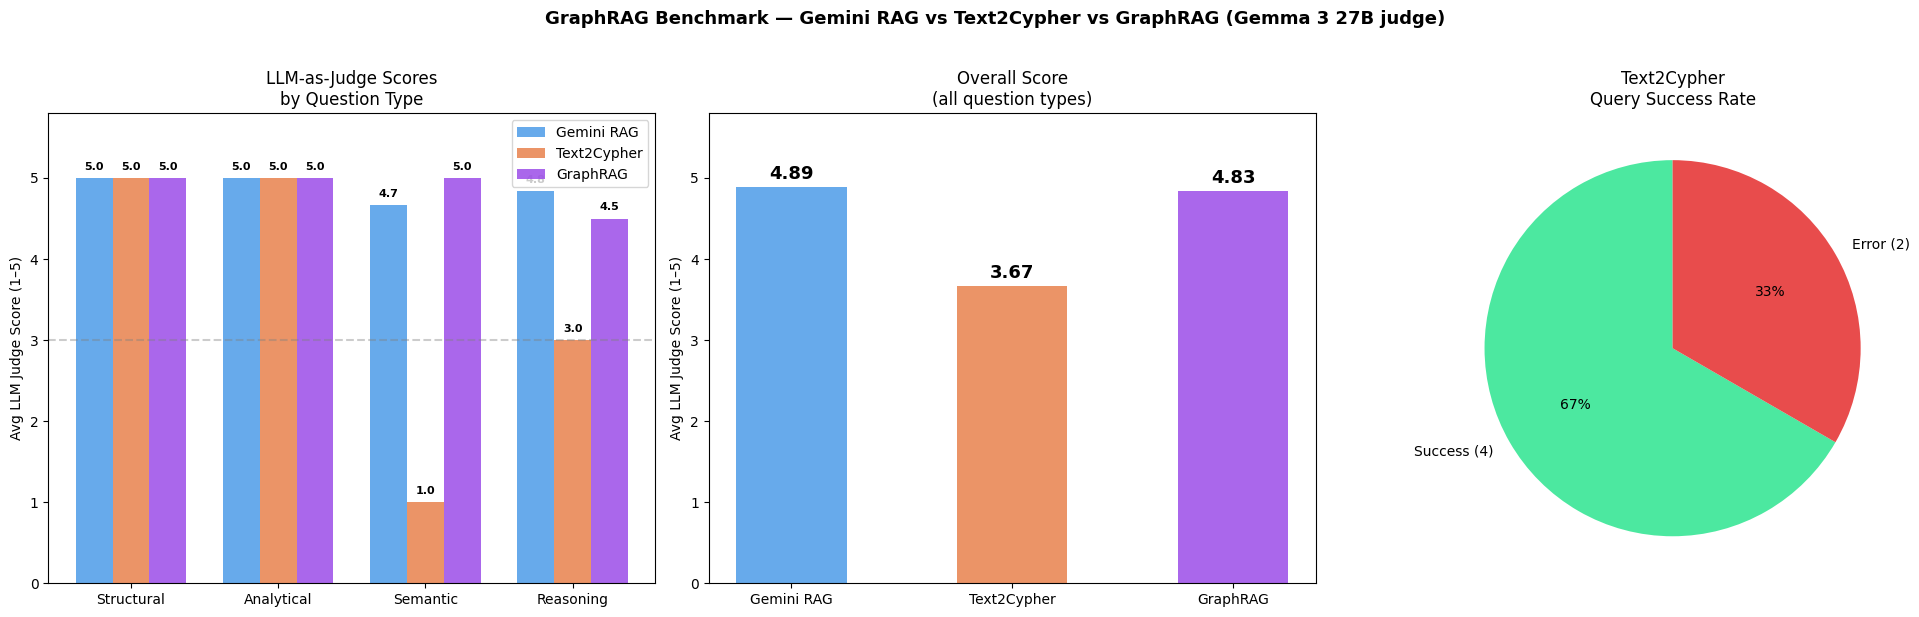

In [47]:

types_order = ["structural", "analytical", "semantic", "reasoning"]
type_labels = {"structural": "Structural", "analytical": "Analytical",
               "semantic": "Semantic", "reasoning": "Reasoning"}

gem_by_type = {t: [] for t in types_order}
t2c_by_type = {t: [] for t in types_order}
grg_by_type = {t: [] for t in types_order}
for r in results_log:
    gem_by_type[r["type"]].append(r["gem_judge"]["avg"])
    t2c_by_type[r["type"]].append(r["t2c_judge"]["avg"])
    grg_by_type[r["type"]].append(r["grg_judge"]["avg"])

gem_avgs = [np.mean(gem_by_type[t]) if gem_by_type[t] else 0 for t in types_order]
t2c_avgs = [np.mean(t2c_by_type[t]) if t2c_by_type[t] else 0 for t in types_order]
grg_avgs = [np.mean(grg_by_type[t]) if grg_by_type[t] else 0 for t in types_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: LLM Judge scores by question type ──
ax  = axes[0]
x   = np.arange(len(types_order))
w   = 0.25
b1  = ax.bar(x - w,   gem_avgs, w, label="Gemini RAG",  color="#4C9BE8", alpha=0.85)
b2  = ax.bar(x,       t2c_avgs, w, label="Text2Cypher", color="#E8824C", alpha=0.85)
b3  = ax.bar(x + w,   grg_avgs, w, label="GraphRAG",    color="#9B4CE8", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([type_labels[t] for t in types_order])
ax.set_ylim(0, 5.8)
ax.set_ylabel("Avg LLM Judge Score (1–5)")
ax.set_title("LLM-as-Judge Scores\nby Question Type")
ax.axhline(3, color="gray", linestyle="--", alpha=0.4)
ax.legend()
for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f"{h:.1f}",
                ha="center", fontsize=8, fontweight="bold")

# ── Plot 2: Overall avg score ──
ax = axes[1]
overall_gem = np.mean([r["gem_judge"]["avg"] for r in results_log])
overall_t2c = np.mean([r["t2c_judge"]["avg"] for r in results_log])
overall_grg = np.mean([r["grg_judge"]["avg"] for r in results_log])
bars = ax.bar(["Gemini RAG", "Text2Cypher", "GraphRAG"],
              [overall_gem, overall_t2c, overall_grg],
              color=["#4C9BE8", "#E8824C", "#9B4CE8"], alpha=0.85, width=0.5)
ax.set_ylim(0, 5.8)
ax.set_ylabel("Avg LLM Judge Score (1–5)")
ax.set_title("Overall Score\n(all question types)")
for bar, val in zip(bars, [overall_gem, overall_t2c, overall_grg]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.2f}",
            ha="center", fontsize=13, fontweight="bold")

# ── Plot 3: Text2Cypher success rate ──
ax = axes[2]
t2c_success = sum(1 for r in results_log if not r["t2c_error"])
t2c_fail    = len(results_log) - t2c_success
ax.pie([t2c_success, t2c_fail],
       labels=[f"Success ({t2c_success})", f"Error ({t2c_fail})"],
       colors=["#4CE8A0", "#E84C4C"], autopct="%1.0f%%", startangle=90)
ax.set_title("Text2Cypher\nQuery Success Rate")

plt.suptitle("GraphRAG Benchmark — Gemini RAG vs Text2Cypher vs GraphRAG (Gemma 3 27B judge)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 11. Answer Comparison per Question

In [48]:

for i, r in enumerate(results_log):
    print(f"{'='*70}")
    print(f"Q{i+1} [{r['type'].upper()}]: {r['question']}")
    print(f"{'─'*70}")
    g = r["gem_judge"]
    print(f"[Gemini RAG]  Judge: correctness={g['correctness']} completeness={g['completeness']} clarity={g['clarity']} → avg={g['avg']}")
    print(f"  Retrieved: {r['gem_top_codes']} | Scores: {r['gem_top_scores']}")
    print(f"  Answer: {r['gem_answer'][:200]}...")
    print(f"{'─'*70}")
    t = r["t2c_judge"]
    print(f"[Text2Cypher] Judge: correctness={t['correctness']} completeness={t['completeness']} clarity={t['clarity']} → avg={t['avg']}")
    print(f"  Cypher: {r['t2c_cypher'][:100]}...")
    print(f"  Answer: {r['t2c_answer'][:200]}...")
    if r["t2c_error"]:
        print(f"  Error: {r['t2c_error'][:120]}")
    print(f"{'─'*70}")
    gg = r["grg_judge"]
    print(f"[GraphRAG]    Judge: correctness={gg['correctness']} completeness={gg['completeness']} clarity={gg['clarity']} → avg={gg['avg']}")
    print(f"  Subgraph ctx: {r['grg_context'][:200]}...")
    print(f"  Answer: {r['grg_answer'][:200]}...")
    print()


Q1 [STRUCTURAL]: Which products are assigned to plant 1903?
──────────────────────────────────────────────────────────────────────
[Gemini RAG]  Judge: correctness=5 completeness=5 clarity=5 → avg=5.0
  Retrieved: ['SOS003L04P', 'SE200G24P', 'SOS008L02P'] | Scores: [0.765, 0.763, 0.757]
  Answer: Product SE200G24P and Product SOS003L04P....
──────────────────────────────────────────────────────────────────────
[Text2Cypher] Judge: correctness=5 completeness=5 clarity=5 → avg=5.0
  Cypher: MATCH (p:Product)-[:ASSIGNED_TO_PLANT]->(plant:Plant) WHERE plant.id = '1903' RETURN p...
  Answer: Here's a concise list of products assigned to plant 1903, based on the provided data:

*   MAR02K12P
*   MAR01K24P
*   SE500G24P
*   SE200G24P
*   MASR025K
*   ATN02K12P
*   ATN01K24P
*   AT5X5K...
──────────────────────────────────────────────────────────────────────
[GraphRAG]    Judge: correctness=5 completeness=5 clarity=5 → avg=5.0
  Subgraph ctx: [SEED NODE] Product SOS003L04P | Group S | Subgroup

## 12. Summary Table & Conclusion

In [49]:

# Per-question scores
rows = []
for r in results_log:
    g, t, gg = r["gem_judge"], r["t2c_judge"], r["grg_judge"]
    scores = {"Gemini RAG": g["avg"], "Text2Cypher": t["avg"], "GraphRAG": gg["avg"]}
    winner = max(scores, key=scores.get)
    rows.append({
        "Question":     r["question"][:50] + "...",
        "Type":         r["type"],
        "Gemini avg":   g["avg"],
        "T2C avg":      t["avg"],
        "GraphRAG avg": gg["avg"],
        "Winner":       winner,
    })

display(pd.DataFrame(rows))

# Overall
overall_gem = np.mean([r["gem_judge"]["avg"] for r in results_log])
overall_t2c = np.mean([r["t2c_judge"]["avg"] for r in results_log])
overall_grg = np.mean([r["grg_judge"]["avg"] for r in results_log])

summary = pd.DataFrame({
    "Approach":        ["Gemini RAG",          "Text2Cypher",                  "GraphRAG"],
    "Type":            ["Semantic RAG",         "NL2Query (NOT RAG)",           "Graph-traversal RAG"],
    "Retrieval":       ["Top-K cosine sim",     "LLM-generated Cypher",         "Cosine sim → graph traversal"],
    "Context":         ["K flat doc texts",     "Exact DB results",             "Subgraph (nodes + edges)"],
    "LLM Judge (avg)": [round(overall_gem, 2), round(overall_t2c, 2),          round(overall_grg, 2)],
    "Strength":        ["Open-ended questions", "Exact lookups & aggregations", "Relational & similarity questions"],
    "Weakness":        ["Misses exact counts",  "Fails on open-ended queries",  "Limited by seed node selection"],
})
display(summary)

print(f"""
CONCLUSION:
─────────────────────────────────────────────────────────
• Gemini RAG    → Judge avg: {overall_gem:.2f}/5
  Flat retrieval of top-K product descriptions.
  Good for open-ended questions, limited by context size.

• Text2Cypher   → Judge avg: {overall_t2c:.2f}/5
  Direct graph queries — perfect for structured lookups.
  Fails completely on fuzzy / comparative questions.

• GraphRAG      → Judge avg: {overall_grg:.2f}/5
  TRUE GraphRAG: vector search → graph traversal →
  subgraph context (seed + 2-hop neighbors via shared plants).
  Context encodes graph topology, not just individual docs.
  Best for relational reasoning and similarity questions.

→ Best strategy: route by intent.
  Structured query  → Text2Cypher
  Semantic/relational → GraphRAG
  Open-ended narrative → Gemini RAG
─────────────────────────────────────────────────────────
""")


,Question,Type,Gemini avg,T2C avg,GraphRAG avg,Winner
0,Which products are assigned to plant 1903?...,structural,5.00,5.0,5.0,Gemini RAG
1,Which products belong to group A?...,structural,5.00,5.0,5.0,Gemini RAG
2,What is the total delivery in units for produc...,analytical,5.00,5.0,5.0,Gemini RAG
3,Which products are most similar to AT5X5K in t...,semantic,4.67,1.0,5.0,GraphRAG
4,"Based on production and delivery data, which p...",reasoning,5.00,5.0,5.0,Gemini RAG
5,Compare the operational profiles of group A ve...,reasoning,4.67,1.0,4.0,Gemini RAG


,Approach,Type,Retrieval,Context,LLM Judge (avg),Strength,Weakness
0,Gemini RAG,Semantic RAG,Top-K cosine sim,K flat doc texts,4.89,Open-ended questions,Misses exact counts
1,Text2Cypher,NL2Query (NOT RAG),LLM-generated Cypher,Exact DB results,3.67,Exact lookups & aggregations,Fails on open-ended queries
2,GraphRAG,Graph-traversal RAG,Cosine sim → graph traversal,Subgraph (nodes + edges),4.83,Relational & similarity questions,Limited by seed node selection



CONCLUSION:
─────────────────────────────────────────────────────────
• Gemini RAG    → Judge avg: 4.89/5
  Flat retrieval of top-K product descriptions.
  Good for open-ended questions, limited by context size.

• Text2Cypher   → Judge avg: 3.67/5
  Direct graph queries — perfect for structured lookups.
  Fails completely on fuzzy / comparative questions.

• GraphRAG      → Judge avg: 4.83/5
  TRUE GraphRAG: vector search → graph traversal →
  subgraph context (seed + 2-hop neighbors via shared plants).
  Context encodes graph topology, not just individual docs.
  Best for relational reasoning and similarity questions.

→ Best strategy: route by intent.
  Structured query  → Text2Cypher
  Semantic/relational → GraphRAG
  Open-ended narrative → Gemini RAG
─────────────────────────────────────────────────────────

